# Module 1 Session 6 -- Working with files and data

## Part I - Recap

In [2]:
# Try to make a habit of using the pathlib package to reference paths and get to documents
from pathlib import Path

# print current directory
print("The current path we is", Path.cwd())

# save home directory as variable and print it
home_dir = Path.home()
print("My home directory is", home_dir)


The current path we is c:\Users\smuelle4\Miniconda3\envs\jlab\Scripts\recode
My home directory is C:\Users\smuelle4


In [3]:
# We defined a function to search Path directories for specific files
def find_file(directory, filename):
    """
    This function takes the directory input and tries to find the
    specified filename inside of it in a recursive way using rglob()
    from pathlib.
    """
    for path in directory.rglob(filename):
        return path
    print(f"I couldn't find the {filename} in {directory}")

In [4]:
# We searched for the two files that we downloaded from the GitHub Repository, saved the path and made sure the files do exist
example_file = find_file(home_dir, "example_data.dat")
test_file = find_file(home_dir, "test.dat")
# print the path to the files
print(example_file, test_file)
# test, if files really exist with .exists()
print(example_file.exists(), test_file.exists())

C:\Users\smuelle4\Downloads\example_data.dat C:\Users\smuelle4\Downloads\test.dat
True True


## Part II -- Recap opening the files with plain Python

In [5]:
# We read line by line of the example_data.dat using built-in Python
with example_file.open("r") as file:  # "r" for reading, "w" for writing, both can be used too at the same time
    lines = file.readlines()
    print(lines)

['# X Y\n', '1.0 2.5\n', '2.0 3.1\n', '3.0 NaN\n', '4.0 5.7\n', 'NaN 6.8\n', '6.0 7.2\n', '7.0 8.9\n', '8.0 NaN\n', '9.0 10.5\n', '10.0 11.1']


In [6]:
lines

['# X Y\n',
 '1.0 2.5\n',
 '2.0 3.1\n',
 '3.0 NaN\n',
 '4.0 5.7\n',
 'NaN 6.8\n',
 '6.0 7.2\n',
 '7.0 8.9\n',
 '8.0 NaN\n',
 '9.0 10.5\n',
 '10.0 11.1']

In [7]:
# create an empty list to store the data values
data = []
for row in lines:
    if row.startswith("#"):
        continue
    else:
        if "NaN" in row:
            continue
        else:
            # replace the "\n" in every line with "" (meaning: nothing)
            new_row = row.replace("\n", "")
            # Split the resulting string at every space. The result are two variables, 
            # here called x and y, which are both saved simultaneously
            x, y = new_row.split(" ")
            # print("This is x: ", x, type(x), "\tThis is y:", y, type(y))
            
            # convert the string to a float
            x_now_as_a_float = float(x)  # in Java: xNowAsAFloat
            y_now_as_a_float = float(y)
            # append the list (= add something to a list) with a list that contains 
            # the float x and y values
            data.append([x_now_as_a_float, y_now_as_a_float])
data

[[1.0, 2.5],
 [2.0, 3.1],
 [4.0, 5.7],
 [6.0, 7.2],
 [7.0, 8.9],
 [9.0, 10.5],
 [10.0, 11.1]]

## Part III -- Working with data 

After reading the data with plain python, we have a list, which contains other lists, which each contain one pair of x- and y-values.

In [8]:
# Extracting specific rows or specific values from a list of lists

print(data[0]) # this returns the first sub-list inside the list, i.e. the first x- and y-values
print(data[0][0]) # this returns the first entry of the first sub-list, i.e. the very first x-value
print(data[3][1]) # this returns the second entry of the fourth sub-list, i.e. the fourth y-value

[1.0, 2.5]
1.0
7.2


To plot the data, we need to store all x- and y-values in their own list (one list with x-values, one list with y-values)

In [9]:
# Store the X values in a separate list
x_val = []

# for loop to extract and save every X-value individually
for x_v in data:
    x_val.append(x_v[0])

print(x_val)

[1.0, 2.0, 4.0, 6.0, 7.0, 9.0, 10.0]


In [10]:
# We can do the same for Y:
y_val = []

for y_v in data:
    y_val.append(y_v[1])
    
print(y_val)

[2.5, 3.1, 5.7, 7.2, 8.9, 10.5, 11.1]


### Exercise: Create one list for x-, and one list for y-values in a single loop 

In [ ]:
#SOLUTION
x_val = []
y_val = []

for val in data:
    x_val.append(val[0])
    y_val.append(val[1])

## Packages

- External packages can make your life much easier
- They are normally tailored towards specific tasks and contain functions for that specific task 
- There are packages for plotting, data handling, image manipulation, statistics, etc. 
- If you have a reoccuring problem for your area of investigation, it makes sense to check for existing packages. Oftentimes, something already exists

## Recap: Installing packages

- While setting up our environment, we already installed a bunch of packages
- To install new packages, we need to:
    - Open the terminal
    - activate the current environment (conda activate environment_name)
    - conda install -c conda-forge <package_name>

## Plotting Data - Using an external Package

- Python does not contain plot functions directly, we therefore need help from a package 
- Multiple packages for plotting exist. We will use matplotlib, which one of the most commonly used ones
- To import a package, we write "import package_name as abbreviation" 

In [11]:
import matplotlib.pyplot as plt 

# now, when we want to call a function from the matplotlib package, we just need to write plt.function()

# We specifically import the module .pyplot from the matplotlib package, 
# since it provides convenient functions that automatically manage figures and axes for us. 
# It is a specific module of the matplotlib package, and thereby called to be imported with the .pyplot

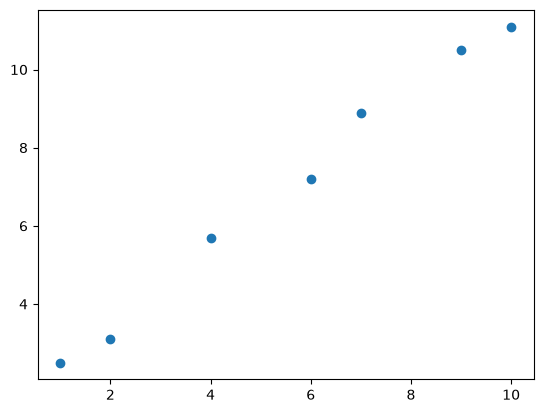

In [12]:
# With the help of matplotlib, we can now plot our X and Y values:
plt.scatter(x_val, y_val) # plt.scatter creates a scatterplot. 
                          # To label the axis, we would need to add more to the function. We will get to that later.

## Reading and handling data the plain pythonic way seems awfully complicated. 

Is there an easier option?

Yes! 

Similar to plotting, packages for handling different kinds of data exist.
For tabular data, numpy and pandas are the most common ones.

We will start with Numpy. The NumPy library and is much faster and more powerful than Python's built-in lists for numerical computations.

In [13]:
#import the numpy package
import numpy as np

The difference between normal list and numpy arrays

In [14]:
# We create two normal Python lists
list_1 = [1,2,3]
list_2 = [4,5,6]

# lets try summarizing the numbers of both lists:
list_1 + list_2

[1, 2, 3, 4, 5, 6]

In [15]:
# Let's create the same lists as numpy arrays:
list_1_nparray = np.array([1,2,3])
list_2_nparray = np.array([4,5,6])

# And do the same operation
list_1_nparray + list_2_nparray

array([5, 7, 9])

A NumPy array is a data structure used in Python to store, index and mathematically work with collections of numbers efficiently.

In [25]:
# converting lists to numpy arrays is as easy as this:
list_1_np = np.array(list_1)

In [26]:
# printing the results only shows minor differences
print(list_1)
print(list_1_np)

[1, 2, 3]
[1 2 3]


In [27]:
# looking at the variables directly (without printing gives) more information
list_1

[1, 2, 3]

In [28]:
list_1_np # here, "array" is also given, indicating that it is indeed a numpy array, which you would otherwise not notice

array([1, 2, 3])

In [29]:
# You can also print the types to make sure:
print(type(list_1))
print(type(list_1_np))

<class 'list'>
<class 'numpy.ndarray'>


In [30]:
# Numpy also has many built-in mathematical operations. 
# For example, let's consider calculating the mean of a list of numbers

# With plain Python lists, we have to implement the calculation ourselves:
list_3 = [1,2,3,4,5]

mean = sum(list_3) / len(list_3)
print(mean)

# With numpy, we can just use np.mean(list). 
mean_np = np.mean(list_3) # Notice that, in this case, we do not specifically need to convert the list to a numpy array
                          # The numpy function does that for us. But if, as in the example above, we perform mathematical operations
                          # without explicitely calling a numpy function, we need to convert the lists ourselves to let Python know that 
                          # it should handle the lists as numpy arrays? 
                          # Additionally, indexing multidimensional data is much closer to math and somewhat more intuitive.
print(mean_np)

3.0
3.0


Let's consider our example data from before

In [31]:
data

[[1.0, 2.5],
 [2.0, 3.1],
 [4.0, 5.7],
 [6.0, 7.2],
 [7.0, 8.9],
 [9.0, 10.5],
 [10.0, 11.1]]

In [32]:
# Converting multidimensional data into a numpy array is also simple:
data_np = np.array(data)

# The result is a 2-dimensional NumPy array (also called a matrix)
print(data_np)

[[ 1.   2.5]
 [ 2.   3.1]
 [ 4.   5.7]
 [ 6.   7.2]
 [ 7.   8.9]
 [ 9.  10.5]
 [10.  11.1]]


Indexing is now more intuitive

In [36]:
# Remember that we had to use a for loop to extract the individual x- and y-values from the list of lists.
# With numpy, this is really simple. The two dimensional index is treated as you would treat a 2D matrix.
# The first entry refers to the rows, the second to the columns. 

# To extract all x-values, you do this in one line:
x_val_np = data_np[:,0] # the colon indicates that you want to have all entries from this dimension

# Compare the x-values:
print("The values of this list are: ", x_val, "; The type of this list of x-values is: ", type(x_val))
print("The values of the numpy array are: ",x_val_np, "; The type of this list of x-values is: ", type(x_val_np))

The values of this list are:  [1.0, 2.0, 4.0, 6.0, 7.0, 9.0, 10.0] ; The type of this list of x-values is:  <class 'list'>
The values of the numpy array are:  [ 1.  2.  4.  6.  7.  9. 10.] ; The type of this list of x-values is:  <class 'numpy.ndarray'>


In [39]:
# Access individual values is also easy

data_np[3,1] # this returns the value in the fourth row and the second column


np.float64(7.2)

Changing variables is easy, but be careful!

In [43]:
# If you want to change a value, it makes sense to copy the data first (in case you mess up, there is an easy rollback)
# Just creating a new variable equal to the old variable is not enough, since the new variable will point towards the same
# position on the drive, and both variables will adapt to changes. 
# An example:
 
data_np_pot_copy = data_np # we create what we think is a copy
data_np_pot_copy[2,0] = 12. # we change the third entry in the first column to 12.

print(data_np) # If we now look at the old data, the entry at position [2,0] is also changed to 12

[[ 1.   2.5]
 [ 2.   3.1]
 [12.   5.7]
 [ 6.   7.2]
 [ 7.   8.9]
 [ 9.  10.5]
 [10.  11.1]]


In [44]:
# To avoid this, we need to explicitely use the .copy() function

data_np = np.array(data) # we create the original data_np again, since it was changed in the cell before

data_np_real_copy = data_np.copy() # we create a real copy with .copy()
data_np_real_copy[2,0] = 12. # we change the third entry in the first column to 12.

print(data_np) # If we now look at the old data, the entry at position [2,0] is still 4.


[[ 1.   2.5]
 [ 2.   3.1]
 [ 4.   5.7]
 [ 6.   7.2]
 [ 7.   8.9]
 [ 9.  10.5]
 [10.  11.1]]


### Exercise - Ask ChatGPT or do it yourself: use numpy to load the data and skip nan values

Useful functions: np.loadtxt, np.isnan, .any

In [48]:
# In numpy, we can use np.loadtxt to load a file
np_data = np.loadtxt(example_file)
print(np_data)

[[ 1.   2.5]
 [ 2.   3.1]
 [ 3.   nan]
 [ 4.   5.7]
 [ nan  6.8]
 [ 6.   7.2]
 [ 7.   8.9]
 [ 8.   nan]
 [ 9.  10.5]
 [10.  11.1]]


Getting rid of the nan values is more tricky

In [49]:
# This is the full code, we will break it down below
np_data_no_nan = np_data[~np.isnan(np_data).any(axis=1)] # this combines multiple functions that are called one after another
np_data_no_nan

array([[ 1. ,  2.5],
       [ 2. ,  3.1],
       [ 4. ,  5.7],
       [ 6. ,  7.2],
       [ 7. ,  8.9],
       [ 9. , 10.5],
       [10. , 11.1]])

In [50]:
# the first called function is np.isnan(np_data).
# This returns a numpy array with the same number of entries at the same positions,
# with True/False (a boolean) for every entry in the data.
# It is False, if the entry is not nan, and True, if it is
np.isnan(np_data)

array([[False, False],
       [False, False],
       [False,  True],
       [False, False],
       [ True, False],
       [False, False],
       [False, False],
       [False,  True],
       [False, False],
       [False, False]])

In [52]:
# The second function we call is .any(). This tests, whether any array element along a given axis evaluates to True.
# In our case, this means that if any value in axis=1 (in this case: the rows) is True, the result will be True. 
# The final result is a numpy array that has as many entries as the investigated axis (here, axis = 1 means the rows).
# Each entry in this array is either True or False. 
# Translated to our problem: if a row contains a nan-value, the entry in this list will be True. Otherwise, it will be False.
np.isnan(np_data).any(axis=1)

array([False, False,  True, False,  True, False, False,  True, False,
       False])

In [61]:
# Right now, if a row contains a nan-value, the entry in this list will be True. Otherwise, it will be False.
# We need the opposite, since we only want to keep rows without nan-values. 
# This can be done by using the "~" symbol, which swaps True to False and vice-versa
~np.isnan(np_data).any(axis=1)

array([ True,  True, False,  True, False,  True,  True, False,  True,
        True])

In [63]:
# Now, we just need to use this result to index our data. 
# All True rows will be kept, all False rows will be removed
np_data_no_nan = np_data[~np.isnan(np_data).any(axis=1)]
np_data_no_nan

array([[ 1. ,  2.5],
       [ 2. ,  3.1],
       [ 4. ,  5.7],
       [ 6. ,  7.2],
       [ 7. ,  8.9],
       [ 9. , 10.5],
       [10. , 11.1]])

In [ ]:
print(np_data_no_nan[:,0]) # -> these are our x-values without nan
print(np_data_no_nan[:,1]) # -> these are our y-values without nan

[ 1.  2.  4.  6.  7.  9. 10.]
[ 2.5  3.1  5.7  7.2  8.9 10.5 11.1]


## Loading and handling tabular data is even easier with Pandas

- Pandas employs a dataframe structure, similar to R
- This makes it easy to load tabular data, call individual columns and rows, and index specific values
- Also, adding new data or combining it with other dataframes is really easy

In [65]:
# First, we import the package
import pandas as pd

In [66]:
# Reading all kinds of tabular data formats is a one liner -> just call pd.read_csv() and provide the path to the file you want to load.
df = pd.read_csv(example_file)

# or is it? Lets inspect the dataframe:
df # Oh no. Everything is pressed into a single column...

,# X Y
0,1.0 2.5
1,2.0 3.1
2,3.0 NaN
3,4.0 5.7
4,NaN 6.8
5,6.0 7.2
6,7.0 8.9
7,8.0 NaN
8,9.0 10.5
9,10.0 11.1


In [69]:
# This is because pandas needs to assume some symbol which separates the different columns of the data.
# The default is a "," separator, since english .csv files use exactly this to separate the columns. 
# Luckily, we can change the separator to say pandas, how the columns in our data are separated.
# This line reads our data correctly. It is still a one-liner. 
# "\s+" means space separated. You could also use " ". 
# With the names-variable, we tell pandas how to name our columns. 
# Since the first line in our data is commented ("#"), we need to provide this information as well. The commented line is then skipped.

df = pd.read_csv(example_file, sep=r"\s+", comment="#", names=["X", "Y"])
df

,X,Y
0,1.0,2.5
1,2.0,3.1
2,3.0,NaN
3,4.0,5.7
4,NaN,6.8
5,6.0,7.2
6,7.0,8.9
7,8.0,NaN
8,9.0,10.5
9,10.0,11.1


Several built-in functions provide a very easy overview of the data

In [70]:
#df.info() returns a general info on the dataset: Number of columns and entries, data types, column names, etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       9 non-null      float64
 1   Y       8 non-null      float64
dtypes: float64(2)
memory usage: 292.0 bytes


In [71]:
# df.head(): prints the first 5 rows
df.head()

,X,Y
0,1.0,2.5
1,2.0,3.1
2,3.0,NaN
3,4.0,5.7
4,NaN,6.8


In [72]:
# df.describe(): caclulates basic statistics
df.describe()

,X,Y
count,9.000000,8.000000
mean,5.555556,6.975000
std,3.205897,3.159905
min,1.000000,2.500000
25%,3.000000,5.050000
50%,6.000000,7.000000
75%,8.000000,9.300000
max,10.000000,11.100000


## Indexing in Pandas (we will dive deeper next week)
Indexing in pandas is easy:

In [73]:
# print the column by using its name. For column X:
print(df["X"])

0     1.0
1     2.0
2     3.0
3     4.0
4     NaN
5     6.0
6     7.0
7     8.0
8     9.0
9    10.0
Name: X, dtype: float64


In [74]:
# You can also index the data in the same way as with numpy (rows first, columns second):
# the function .iloc[] simulates the indexing of numpy.
# To get e.g., the entry of the second row and the first column, just call:
df.iloc[1,0]

np.float64(2.0)

In [75]:
# Or a complete column (all rows of column 1):
df.iloc[:,0]

0     1.0
1     2.0
2     3.0
3     4.0
4     NaN
5     6.0
6     7.0
7     8.0
8     9.0
9    10.0
Name: X, dtype: float64

In [77]:
# With .loc[] you can do the same, but need to specify the column by name and not by index
df.loc[1,"X"]

np.float64(2.0)

Getting rid of rows with nan-values is also super easy in pandas:

In [78]:
# df.dropna() can be used to get rid of rows with nan-values easily
df_nonan = df.dropna()
df_nonan

,X,Y
0,1.0,2.5
1,2.0,3.1
3,4.0,5.7
5,6.0,7.2
6,7.0,8.9
8,9.0,10.5
9,10.0,11.1


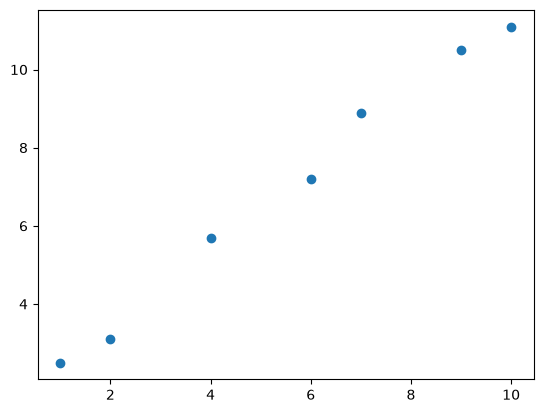

In [79]:
# Now we can plot the data using the pandas dataframe
plt.scatter(df_nonan.loc[:,"X"], df_nonan["Y"])

## Exercise 
    - Load the second file (test.dat)  
    (can be found here https://github.com/BAMresearch/RECODE/tree/main/docs/module1-foundations_of_python_coding/module1s5, but is already loaded -> see the first cells of this notebook)
    - Use Pandas to load the file, be aware of this files separator and the header
    - Use Pandas functions to get a quick overview of the data
    - Plot the different columns against each other

## Additional Exercise:

I zipped 30 .csv-files that each contain a random, synthetic spectrum and uploaded the .zip here: https://github.com/BAMresearch/RECODE/tree/main/docs/module1-foundations_of_python_coding/module1s6

Every spectrum has 1,000 bands, and for each band we generated an intensity value. 

As an additional exercise, you can

    - Load all files from the synthetic_spectra.zip automatically using a loop that calls Pandas .read_csv() function.
    - Create a single dataframe from the individual spectra files. Every spectrum is supposed to be in one row of the dataframe, 
    every column is supposed to be one band.
    - Set all values below 0 to 0.
    - Plot the spectra 1, 6, 8, and 18 in a single plot. Each spectra should have a different color.

This exercise requires functions and operations that were not shown in the course yet, you can still try to get to the result by using Google and/or your favourite LLM. 
While you can access .zip-files with Python, its probably best to unzip the spectra in a new folder first.